<a href="https://www.kaggle.com/code/tuananhlee/conga?scriptVersionId=268028226" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# PHẦN 1: CÁC THƯ VIỆN
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, pairwise

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess

import warnings
warnings.filterwarnings("ignore")

2025-10-14 14:38:45.095253: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760452725.296779      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760452725.352499      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# PHẦN 2: ĐỌC DỮ LIỆU & KHẢO SÁT
df_labels = pd.read_csv("/kaggle/input/owoo1234/labels.csv")
train_dir = '/kaggle/input/owoo1234/train'
test_dir  = '/kaggle/input/owoo1234/test'

df_labels["id"] = df_labels["id"].apply(lambda x: x + ".jpg")

# Lấy ra 10 giống chó xuất hiện nhiều nhất
breed_counts = df_labels['breed'].value_counts()
top_10_breeds = breed_counts.head(10).index.tolist()

print("10 giống chó xuất hiện nhiều nhất (dùng để huấn luyện các mô hình supervised):")
print(top_10_breeds)

# Lấy danh sách tất cả các giống chó để dùng cho ZSL
all_breeds = sorted(df_labels['breed'].unique().tolist())
print(f"\nTổng cộng có {len(all_breeds)} giống chó trong bộ dữ liệu (dùng cho ZSL).")


10 giống chó xuất hiện nhiều nhất (dùng để huấn luyện các mô hình supervised):
['scottish_deerhound', 'maltese_dog', 'afghan_hound', 'entlebucher', 'bernese_mountain_dog', 'shih-tzu', 'pomeranian', 'great_pyrenees', 'basenji', 'samoyed']

Tổng cộng có 120 giống chó trong bộ dữ liệu (dùng cho ZSL).


In [3]:
# TẠO DỮ LIỆU THUỘC TÍNH
attributes = [
    'is_small', 'is_medium', 'is_large', 'has_long_fur', 'has_short_fur',
    'has_floppy_ears', 'has_pointed_ears', 'has_short_muzzle', 'has_long_muzzle',
]

In [4]:
# Tạo dữ liệu ngẫu nhiên nhưng 
np.random.seed(42)
attribute_data = np.random.rand(len(all_breeds), len(attributes))
attribute_df = pd.DataFrame(attribute_data, columns=attributes)
attribute_df.insert(0, 'breed', all_breeds)

# Tinh chỉnh một vài giống chó quen thuộc cho hợp lý hơn
def set_attrs(breed, attrs):
    idx = attribute_df[attribute_df['breed'] == breed].index[0]
    for attr, val in attrs.items():
        attribute_df.loc[idx, attr] = val

In [5]:
# Chỉnh sửa các giống trong top 10
set_attrs('scottish_deerhound', {'is_small': 0, 'is_medium': 0.1, 'is_large': 1, 'has_long_fur': 0.8, 'has_long_muzzle': 0.7, 'has_pointed_ears': 0, 'has_floppy_ears': 0.9})
set_attrs('maltese_dog', {'is_small': 1, 'is_medium': 0.1, 'is_large': 0, 'has_long_fur': 0.8, 'has_short_muzzle': 0.9, 'has_floppy_ears': 0.9, 'has_pointed_ears': 0})
set_attrs('bernese_mountain_dog', {'is_small': 0, 'is_medium': 0.1, 'is_large': 1, 'has_long_fur': 0.9, 'has_long_muzzle': 0.7, 'has_floppy_ears': 0.9, 'has_pointed_ears': 0})
# Chỉnh sửa một vài giống "chưa thấy"
set_attrs('pug', {'is_small': 0.9, 'is_medium': 0.2, 'is_large': 0, 'has_short_fur': 0.9, 'has_short_muzzle': 1, 'has_floppy_ears': 0.8, 'has_pointed_ears': 0})
set_attrs('chihuahua', {'is_small': 1, 'is_medium': 0, 'is_large': 0, 'has_short_fur': 0.8, 'has_short_muzzle': 0.8,'has_pointed_ears': 0.7, 'has_floppy_ears': 0.1})
set_attrs('american_staffordshire_terrier', {'is_small': 0, 'is_medium': 0.2, 'is_large': 1, 'has_short_fur': 0.8,'has_long_muzzle': 0.6, 'has_short_muzzle': 0.3,'has_pointed_ears': 0.9, 'has_floppy_ears': 0})

print("\nMa trận thuộc tính đã được tạo:")
print(attribute_df.head())


Ma trận thuộc tính đã được tạo:
                            breed  is_small  is_medium  is_large  \
0                   affenpinscher  0.374540   0.950714  0.731994   
1                    afghan_hound  0.708073   0.020584  0.969910   
2             african_hunting_dog  0.431945   0.291229  0.611853   
3                        airedale  0.514234   0.592415  0.046450   
4  american_staffordshire_terrier  0.000000   0.200000  1.000000   

   has_long_fur  has_short_fur  has_floppy_ears  has_pointed_ears  \
0      0.598658       0.156019         0.155995          0.058084   
1      0.832443       0.212339         0.181825          0.183405   
2      0.139494       0.292145         0.366362          0.456070   
3      0.607545       0.170524         0.065052          0.948886   
4      0.440152       0.800000         0.000000          0.900000   

   has_short_muzzle  has_long_muzzle  
0          0.866176         0.601115  
1          0.304242         0.524756  
2          0.785176       

In [6]:
# PHẦN 3: CHUẨN BỊ DỮ LIỆU VÀ HUẤN LUYỆN
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# CHIA TẬP DỮ LIỆU
train_df, test_df = train_test_split(df_labels, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42)
train_top = train_df[train_df['breed'].isin(top_10_breeds)].reset_index(drop=True)
val_top = val_df[val_df['breed'].isin(top_10_breeds)].reset_index(drop=True)
test_top = test_df[test_df['breed'].isin(top_10_breeds)].reset_index(drop=True)

In [7]:
# DATA GENERATORS
SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(top_10_breeds)
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')
val_datagen = ImageDataGenerator(rescale=1./255)
train_gen = train_datagen.flow_from_dataframe(dataframe=train_top, directory=train_dir, x_col='id', y_col='breed', target_size=SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=top_10_breeds, shuffle=True, seed=SEED)
val_gen = val_datagen.flow_from_dataframe(dataframe=val_top, directory=train_dir, x_col='id', y_col='breed', target_size=SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=top_10_breeds, shuffle=False)
test_gen = val_datagen.flow_from_dataframe(dataframe=test_top, directory=train_dir, x_col='id', y_col='breed', target_size=SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=top_10_breeds, shuffle=False)

Found 820 validated image filenames belonging to 10 classes.
Found 81 validated image filenames belonging to 10 classes.
Found 240 validated image filenames belonging to 10 classes.


In [8]:
# XÂY DỰNG VÀ HUẤN LUYỆN CNN (XCEPTION)
base_model = Xception(weights='imagenet', include_top=False, input_shape=(SIZE[0], SIZE[1], 3))
base_model.trainable = False
inputs = Input(shape=(SIZE[0], SIZE[1], 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model_cnn = Model(inputs, outputs)
model_cnn.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model_checkpoint = ModelCheckpoint('best_xception_top10.keras', monitor='val_loss', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min')

print("--- BẮT ĐẦU HUẤN LUYỆN CNN ---")
history_cnn = model_cnn.fit(train_gen, epochs=10, validation_data=val_gen, callbacks=[model_checkpoint, early_stopping])
model_cnn.load_weights('best_xception_top10.keras')

I0000 00:00:1760452742.597420      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- BẮT ĐẦU HUẤN LUYỆN CNN ---
Epoch 1/10


I0000 00:00:1760452753.370119      59 service.cc:148] XLA service 0x7d14e0001a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760452753.370871      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760452754.424241      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/26 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.1016 - loss: 2.5296 

I0000 00:00:1760452759.670171      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 965ms/step - accuracy: 0.4176 - loss: 1.8067 - val_accuracy: 0.9136 - val_loss: 0.3597
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 412ms/step - accuracy: 0.9163 - loss: 0.4126 - val_accuracy: 0.9383 - val_loss: 0.2308
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 410ms/step - accuracy: 0.9336 - loss: 0.2638 - val_accuracy: 0.9259 - val_loss: 0.2148
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 373ms/step - accuracy: 0.9109 - loss: 0.2501 - val_accuracy: 0.9259 - val_loss: 0.2202
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 407ms/step - accuracy: 0.9284 - loss: 0.2044 - val_accuracy: 0.9506 - val_loss: 0.1846
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 375ms/step - accuracy: 0.9541 - loss: 0.1797 - val_accuracy: 0.9383 - val_loss: 0.1943
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - accuracy: 0.9388 - loss: 0.1845 - val_accuracy: 0.9383 - val_loss: 0.1832
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 374ms/step - accuracy: 0.9554 - loss: 0.1412 - val_accuracy: 0.925

In [9]:
# TRÍCH XUẤT ĐẶC TRƯNG
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)
train_feature_gen = val_datagen.flow_from_dataframe(dataframe=train_top, directory=train_dir, x_col='id', y_col='breed', target_size=SIZE, batch_size=BATCH_SIZE, class_mode='categorical', classes=top_10_breeds, shuffle=False)
test_feature_gen = test_gen

def extract_features(generator, model, sample_count):
    features = np.zeros(shape=(sample_count, 7, 7, 2048)) # Xception output shape
    labels = np.zeros(shape=(sample_count))
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = model.predict(inputs_batch, verbose=0)
        batch_size = inputs_batch.shape[0]
        features[i * BATCH_SIZE : i * BATCH_SIZE + batch_size] = features_batch
        labels[i * BATCH_SIZE : i * BATCH_SIZE + batch_size] = np.argmax(labels_batch, axis=1)
        i += 1
        if i * BATCH_SIZE >= sample_count:
            break
    return features.reshape(sample_count, -1), labels

print("--- TRÍCH XUẤT ĐẶC TRƯNG ---")
X_train_features, y_train_labels = extract_features(train_feature_gen, feature_extractor, train_top.shape[0])
X_test_features, y_test_labels = extract_features(test_feature_gen, feature_extractor, test_top.shape[0])

print(f"Kích thước đặc trưng tập Train: {X_train_features.shape}")
print(f"Kích thước đặc trưng tập Test: {X_test_features.shape}")

Found 820 validated image filenames belonging to 10 classes.
--- TRÍCH XUẤT ĐẶC TRƯNG ---
Kích thước đặc trưng tập Train: (820, 100352)
Kích thước đặc trưng tập Test: (240, 100352)


In [10]:
# HUẤN LUYỆN RF VÀ XGB
print("\n--- HUẤN LUYỆN RF VÀ XGB ---")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1).fit(X_train_features, y_train_labels)
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=SEED, n_jobs=-1).fit(X_train_features, y_train_labels)


--- HUẤN LUYỆN RF VÀ XGB ---


In [11]:
# HUẤN LUYỆN MÔ HÌNH Zeroshot Learning
print("--- HUẤN LUYỆN MÔ HÌNH ZSL ---")

# 1. Chuẩn bị nhãn thuộc tính cho tập train
attribute_map = attribute_df.set_index('breed').T.to_dict('list')
y_train_attributes = np.array([attribute_map[breed] for breed in train_top['breed']])

# 2. Xây dựng mô hình
num_attributes = y_train_attributes.shape[1]
feature_size = X_train_features.shape[1]

attribute_predictor = tf.keras.models.Sequential([
    Dense(1024, activation='relu', input_shape=(feature_size,)),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_attributes, activation='sigmoid') # Sigmoid cho đầu ra [0, 1]
])

attribute_predictor.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Phù hợp cho dự đoán đa nhãn (multi-label)
    metrics=['accuracy']
)

# 3. Huấn luyện
attribute_predictor.fit(X_train_features, y_train_attributes, epochs=30, batch_size=32, verbose=1)

--- HUẤN LUYỆN MÔ HÌNH ZSL ---
Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.2624 - loss: 3.4391
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3456 - loss: 1.0761
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3555 - loss: 0.7270
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4177 - loss: 0.6359
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4605 - loss: 0.6209
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4971 - loss: 0.6227
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5027 - loss: 0.6021
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5636 - loss: 0.5813
Epoch 9/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5377 - loss: 0.5669
Epoch 10/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5761 - loss: 0.5631
Epoch 11/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5869 - loss: 0.5515
Epoch 12/30
26/26 ━━━━━━━━━━━━━━

In [12]:
# PHẦN 4: ĐÁNH GIÁ CÁC MÔ HÌNH (GIỮ NGUYÊN)

# ĐÁNH GIÁ MÔ HÌNH CNN (XCEPTION)
print("\n--- ĐÁNH GIÁ MÔ HÌNH CNN (XCEPTION) ---")
cnn_loss, cnn_acc = model_cnn.evaluate(test_gen, steps=test_gen.samples // BATCH_SIZE)
print(f"Xception Test Loss: {cnn_loss:.4f}")
print(f"Xception Test Accuracy: {cnn_acc:.4f}")

# Dự đoán nhãn cho ma trận nhầm lẫn
cnn_pred_probs = model_cnn.predict(test_gen, steps=test_gen.samples // BATCH_SIZE + 1)
cnn_pred_labels = np.argmax(cnn_pred_probs, axis=1)

# Lấy nhãn thực tế
true_labels_cnn = test_gen.classes[:len(cnn_pred_labels)]

# Báo cáo phân loại
print("\nClassification Report (Xception):")
print(classification_report(true_labels_cnn, cnn_pred_labels, target_names=top_10_breeds))
## ĐÁNH GIÁ MÔ HÌNH XGBOOST VÀ RANDOM FOREST
print("\n--- ĐÁNH GIÁ MÔ HÌNH XGBOOST VÀ RANDOM FOREST ---")

# --- XGBoost ---
xgb_pred_labels = xgb_model.predict(X_test_features)
print("\nClassification Report (XGBoost):")
print(classification_report(y_test_labels, xgb_pred_labels, target_names=top_10_breeds))

# --- Random Forest ---
rf_pred_labels = rf_model.predict(X_test_features)
print("\nClassification Report (Random Forest):")
print(classification_report(y_test_labels, rf_pred_labels, target_names=top_10_breeds))



--- ĐÁNH GIÁ MÔ HÌNH CNN (XCEPTION) ---
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.9610 - loss: 0.1444
Xception Test Loss: 0.1300
Xception Test Accuracy: 0.9554
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 457ms/step

Classification Report (Xception):
                      precision    recall  f1-score   support

  scottish_deerhound       1.00      0.94      0.97        36
         maltese_dog       0.95      0.95      0.95        20
        afghan_hound       0.95      0.95      0.95        22
         entlebucher       0.97      1.00      0.98        29
bernese_mountain_dog       1.00      0.96      0.98        26
            shih-tzu       0.95      0.95      0.95        22
          pomeranian       1.00      0.90      0.95        21
      great_pyrenees       0.89      0.96      0.92        25
             basenji       0.95      1.00      0.98        20
             samoyed       0.85      0.89      0.87        19

            accuracy                           0.95       240
        

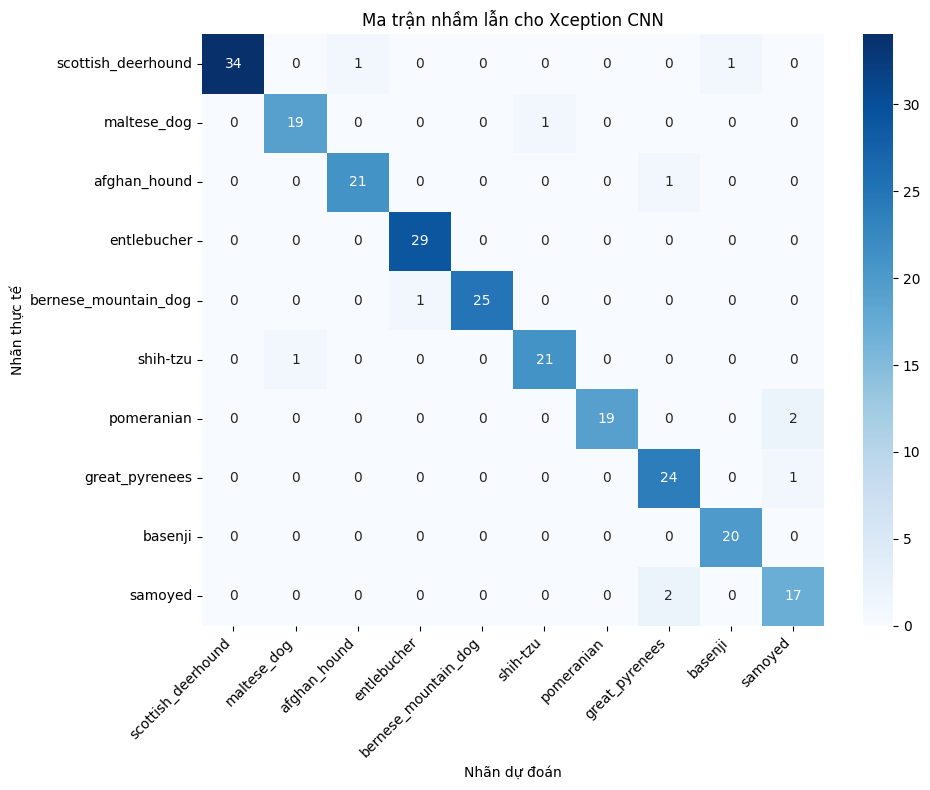

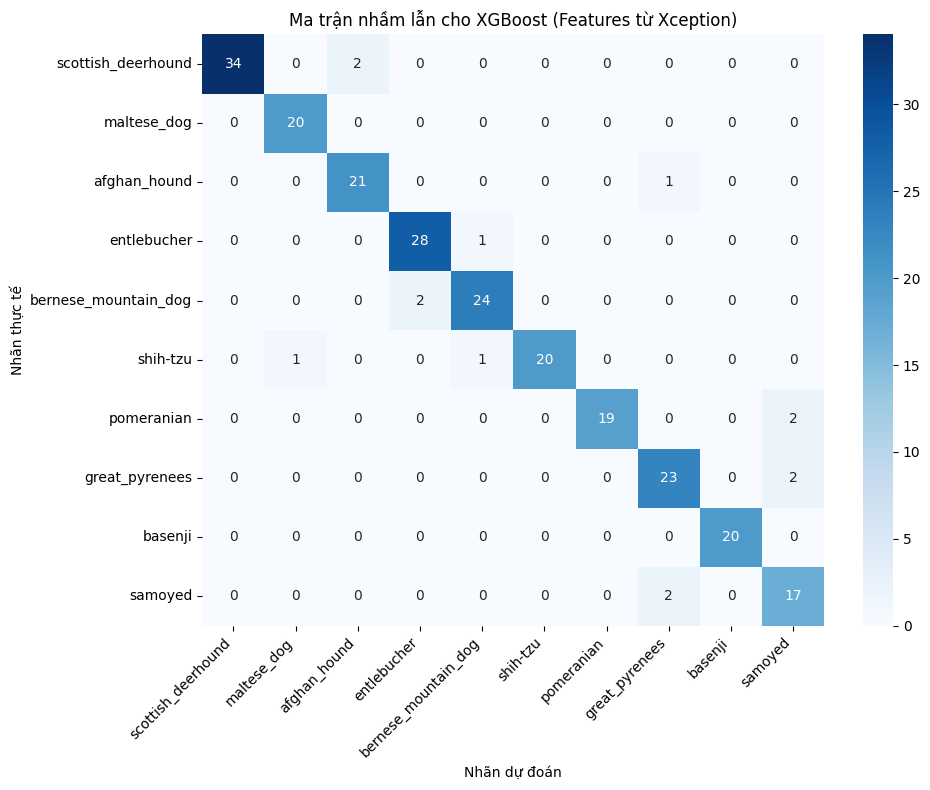

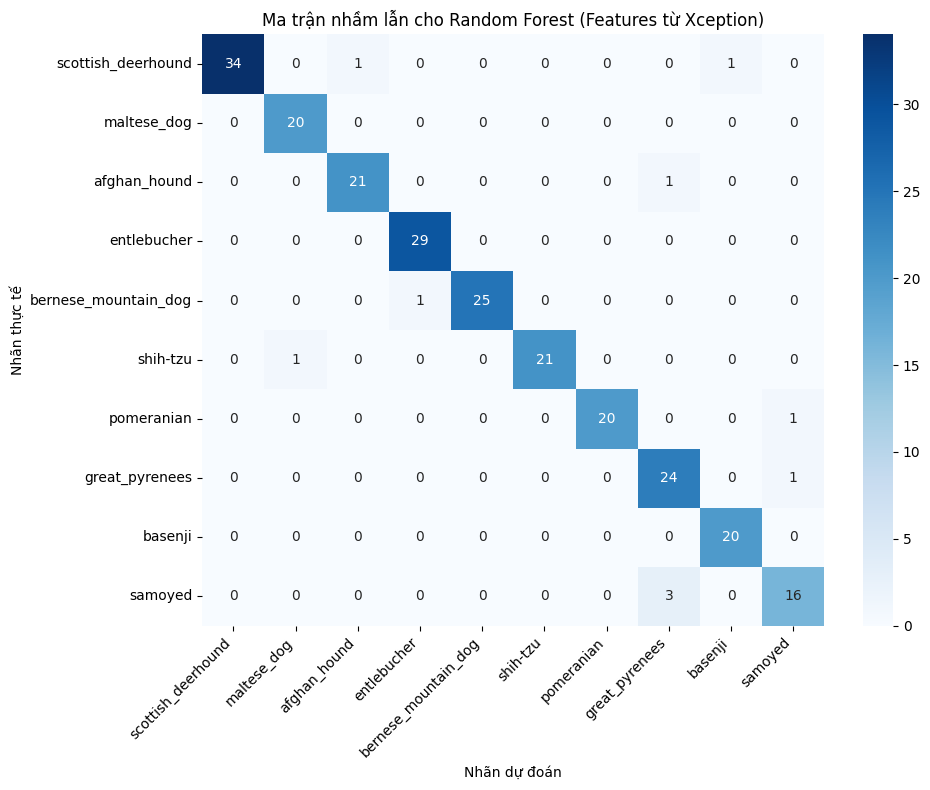

In [13]:
## VẼ MA TRẬN NHẦM LẪN
def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Vẽ ma trận nhầm lẫn."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title(f'Ma trận nhầm lẫn cho {model_name}')
    plt.ylabel('Nhãn thực tế')
    plt.xlabel('Nhãn dự đoán')
    plt.tight_layout()
    plt.show()

# --- Ma trận nhầm lẫn Xception ---
plot_confusion_matrix(
    y_true=true_labels_cnn,
    y_pred=cnn_pred_labels,
    model_name='Xception CNN',
    class_names=top_10_breeds
)

# --- Ma trận nhầm lẫn XGBoost ---
plot_confusion_matrix(
    y_true=y_test_labels,
    y_pred=xgb_pred_labels,
    model_name='XGBoost (Features từ Xception)',
    class_names=top_10_breeds
)

# --- Ma trận nhầm lẫn Random Forest ---
plot_confusion_matrix(
    y_true=y_test_labels,
    y_pred=rf_pred_labels,
    model_name='Random Forest (Features từ Xception)',
    class_names=top_10_breeds
)

In [14]:
# PHẦN 5: XÂY DỰNG HÀM DỰ ĐOÁN 
def predict_zsl_classic(img_features_flat, attribute_predictor, attribute_df):
    """Dự đoán giống chó bằng ZSL ."""
    # 1. Dự đoán vector thuộc tính từ đặc trưng ảnh
    predicted_attributes = attribute_predictor.predict(img_features_flat, verbose=0)

    # 2. Lấy ma trận thuộc tính của tất cả các giống chó
    all_attributes_matrix = attribute_df.drop('breed', axis=1).values
    all_breeds_list = attribute_df['breed'].tolist()

    # 3. Tính độ tương đồng cosine
    similarities = pairwise.cosine_similarity(predicted_attributes, all_attributes_matrix)

    # 4. Sắp xếp và trả về kết quả
    top_k = 5
    top_indices = np.argsort(similarities[0])[::-1][:top_k]

    results = []
    for idx in top_indices:
        breed = all_breeds_list[idx]
        score = similarities[0][idx]
        results.append((breed, score))
    return results


In [15]:
def predict_single(image_path, model_cnn, feature_extractor, xgb_model, rf_model,
                   attribute_predictor, attribute_df, top_10_breeds, SIZE):
    # 1. Load và hiển thị ảnh
    img = keras_image.load_img(image_path, target_size=SIZE)
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Ảnh đầu vào")
    plt.show()

    # 2. Tiền xử lý và trích xuất đặc trưng (chỉ 1 lần)
    img_arr = keras_image.img_to_array(img)
    x = np.expand_dims(img_arr, axis=0)
    x_processed = xception_preprocess(x)
    img_features = feature_extractor.predict(x_processed, verbose=0)
    img_features_flat = img_features.reshape(1, -1)

    # DỰ ĐOÁN VỚI CÁC MÔ HÌNH ĐÃ HUẤN LUYỆN
    print("Kết quả từ các mô hình:")
    # CNN
    probs_cnn = model_cnn.predict(x_processed, verbose=0)
    pred_label_cnn = top_10_breeds[np.argmax(probs_cnn)]
    print(f" CNN (Xception): {pred_label_cnn} (Conf: {np.max(probs_cnn):.2f})")
    # RF
    probs_rf = rf_model.predict_proba(img_features_flat)
    pred_label_rf = top_10_breeds[np.argmax(probs_rf)]
    print(f" Random Forest : {pred_label_rf} (Conf: {np.max(probs_rf):.2f})")
    # XGB
    probs_xgb = xgb_model.predict_proba(img_features_flat)
    pred_label_xgb = top_10_breeds[np.argmax(probs_xgb)]
    print(f" XGBoost       : {pred_label_xgb} (Conf: {np.max(probs_xgb):.2f})")

    #  DỰ ĐOÁN ZERO-SHOT LEARNING 
    zsl_results = predict_zsl_classic(img_features_flat, attribute_predictor, attribute_df)
    print("Kết quả Zero-Shot:")
    for breed, score in zsl_results:
        print(f" - {breed:<30} | Độ tương đồng: {score:.4f}")

In [16]:
# PHẦN 6: LƯU/TẢI MÔ HÌNH VÀ DEMO
#  LƯU MÔ HÌNH 
print("--- LƯU CÁC MÔ HÌNH ĐÃ HUẤN LUYỆN ---")
model_cnn.save('final_xception_classifier.keras')
joblib.dump(xgb_model, 'xgb_model_top10.joblib')
joblib.dump(rf_model, 'rf_model_top10.joblib')
# Lưu mô hình thuộc tính mới
attribute_predictor.save('attribute_predictor_zsl.keras')
print(" Đã lưu thành công 4 mô hình.")

--- LƯU CÁC MÔ HÌNH ĐÃ HUẤN LUYỆN ---
 Đã lưu thành công 4 mô hình.


In [17]:
#TẢI LẠI MÔ HÌNH
print("--- TẢI LẠI CÁC MÔ HÌNH ĐÃ LƯU ---")
loaded_cnn_model = load_model('final_xception_classifier.keras')
loaded_xgb_model = joblib.load('xgb_model_top10.joblib')
loaded_rf_model = joblib.load('rf_model_top10.joblib')
# Tải mô hình thuộc tính mới
loaded_attribute_predictor = load_model('attribute_predictor_zsl.keras')

# Tái tạo Feature Extractor từ model CNN đã tải
base_model_layer = loaded_cnn_model.layers[1]
loaded_feature_extractor = Model(inputs=base_model_layer.input, outputs=base_model_layer.output)
print(" Đã tải lại thành công các mô hình và tái tạo feature extractor.")

--- TẢI LẠI CÁC MÔ HÌNH ĐÃ LƯU ---
 Đã tải lại thành công các mô hình và tái tạo feature extractor.


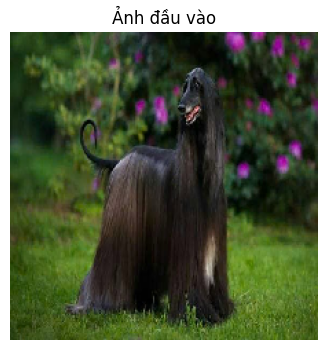

Kết quả từ các mô hình:
 CNN (Xception): afghan_hound (Conf: 0.99)
 Random Forest : afghan_hound (Conf: 0.79)
 XGBoost       : afghan_hound (Conf: 0.99)
Kết quả Zero-Shot:
 - afghan_hound                   | Độ tương đồng: 0.9617
 - irish_setter                   | Độ tương đồng: 0.9560
 - bouvier_des_flandres           | Độ tương đồng: 0.9523
 - chow                           | Độ tương đồng: 0.9444
 - boxer                          | Độ tương đồng: 0.9438


In [18]:
# --- KHU VỰC DEMO ---
sample_img_path = ('/kaggle/input/abcdef/ảnh chó/afghan/3.2afghan_hound.jpg')

predict_single(
    image_path=sample_img_path,
    model_cnn=loaded_cnn_model,
    feature_extractor=loaded_feature_extractor,
    xgb_model=loaded_xgb_model,
    rf_model=loaded_rf_model,
    attribute_predictor=loaded_attribute_predictor, # Thêm vào
    attribute_df=attribute_df, # Thêm vào
    top_10_breeds=top_10_breeds,
    SIZE=SIZE
)